In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory

2026-05-09 20:34:49.580994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778358889.771144      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778358889.827806      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778358890.271940      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778358890.271973      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778358890.271976      57 computation_placer.cc:177] computation placer alr

In [3]:

img_size = 128
batch_size = 32
num_classes = 4
data_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"  


train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


I0000 00:00:1778358914.976631      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


 GPU always has data ready  
 training becomes faster  
 pipeline becomes smoother  

In [4]:

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# =========================
# DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# =========================
# BASE MODEL (EfficientNetB0)
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(img_size, img_size, 3),
    pooling="avg"
)

base_model.trainable = False  # freeze initially

# =========================
# MODEL BUILDING
inputs = layers.Input(shape=(img_size, img_size, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# =========================
# COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
# =========================
# TRAIN (phase 1 - frozen backbone)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =========================
# FINE-TUNING (phase 2)
base_model.trainable = True

# optional: freeze early layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =========================
# SAVE MODEL
model.save("brain_tumor_model.h5")

Epoch 1/10


E0000 00:00:1778358990.011907      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778358992.436337     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.5540 - loss: 1.0393 - val_accuracy: 0.7830 - val_loss: 0.5591
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7873 - loss: 0.5714 - val_accuracy: 0.7946 - val_loss: 0.5397
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8085 - loss: 0.5229 - val_accuracy: 0.8295 - val_loss: 0.4657
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8252 - loss: 0.4724 - val_accuracy: 0.8116 - val_loss: 0.4857
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8308 - loss: 0.4501 - val_accuracy: 0.8214 - val_loss: 0.4559
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8271 - loss: 0.4553 - val_accuracy: 0.8250 - val_loss: 0.4484
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8544 - loss: 0.4102 - val_accuracy: 0.8321 - val_loss: 0.4437
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8332 - loss: 0.4361 - val_accuracy: 0.82

E0000 00:00:1778359051.539190      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.7016 - loss: 0.7642 - val_accuracy: 0.8161 - val_loss: 0.4743
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7574 - loss: 0.6050 - val_accuracy: 0.8107 - val_loss: 0.4992
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7791 - loss: 0.5739 - val_accuracy: 0.8098 - val_loss: 0.4900
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8040 - loss: 0.5205 - val_accuracy: 0.8161 - val_loss: 0.4744
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8209 - loss: 0.4890 - val_accuracy: 0.8250 - val_loss: 0.4522
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8289 - loss: 0.4597 - val_accuracy: 0.8339 - val_loss: 0.4350
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8317 - loss: 0.4482 - val_accuracy: 0.8339 - val_loss: 0.4296
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8365 - loss: 0.4328 - val_accuracy: 0.84

In [17]:
import cv2
import numpy as np
img = cv2.imread("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_100.jpg")
img = cv2.resize(img, (128, 128))
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
class_index = np.min(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


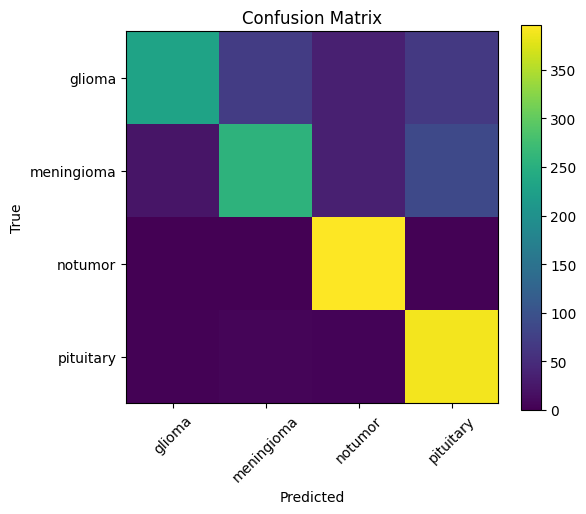

              precision    recall  f1-score   support

      glioma       0.91      0.57      0.70       400
  meningioma       0.77      0.64      0.70       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.72      0.97      0.82       400

    accuracy                           0.79      1600
   macro avg       0.81      0.79      0.78      1600
weighted avg       0.81      0.79      0.78      1600



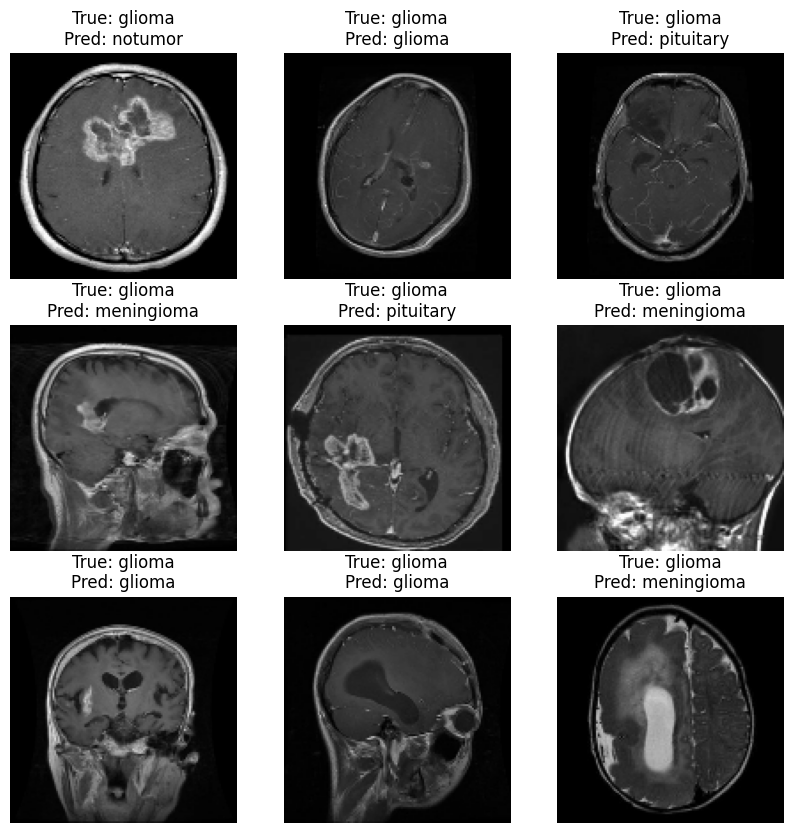

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


test_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

img_size = 128
batch_size = 32


test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=False
)

class_names = test_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")

plt.show()